# Evaluation Metrics for Classification
In the previous session we trained a model for predicting churn. How do we know if it's good?

# 4.1 Evaluation metrics
- Dataset: [Kaggle](https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv)
- In this dataset our desired target for classification task will be `converted` variable - has the client signed up to the platform or not.

In [94]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mutual_info_score, accuracy_score

In [95]:
# Paths
base_path = Path.cwd()
file_path = base_path / "data" / "course_lead_scoring.csv"
df = pd.read_csv(file_path)

In [96]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lead_source               1334 non-null   str    
 1   industry                  1328 non-null   str    
 2   number_of_courses_viewed  1462 non-null   int64  
 3   annual_income             1281 non-null   float64
 4   employment_status         1362 non-null   str    
 5   location                  1399 non-null   str    
 6   interaction_count         1462 non-null   int64  
 7   lead_score                1462 non-null   float64
 8   converted                 1462 non-null   int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 102.9 KB


# 4.2 EDA
- Check missing values
- Look at the target variable (`converted`)
- Look at numerical and categorical variables

In [97]:
categorical_columns = list(df.dtypes[df.dtypes == 'str'].index)

In [140]:
categorical_columns

['lead_source', 'industry', 'employment_status', 'location']

In [98]:
numerical_columns = list(df.dtypes[df.dtypes != 'str'].index)

### Missing values

In [99]:
df[categorical_columns].isnull().sum()

lead_source          128
industry             134
employment_status    100
location              63
dtype: int64

In [100]:
df[categorical_columns].nunique()

lead_source          5
industry             7
employment_status    4
location             7
dtype: int64

In [101]:
df[numerical_columns].isnull().sum()

number_of_courses_viewed      0
annual_income               181
interaction_count             0
lead_score                    0
converted                     0
dtype: int64

In [102]:
numerical_columns.remove('converted') # removed target variable from numerical features

In [103]:
df[categorical_columns] = df[categorical_columns].fillna('NA')
df[numerical_columns] = df[numerical_columns].fillna(0)

# 4.3 Setting up the validation framework

<div style="margin-left: 0; text-align: left; font-family: Arial, sans-serif;">

<h3>Dataset Split Workflow</h3>

<div style="display: flex; width: 720px; border: 2px solid black; height: 70px; margin-bottom: 20px;">
  <div style="width: 60%; border-right: 2px solid black; display: flex; align-items: center; justify-content: center; font-size: 20px;">
    <b>TRAIN (60%)</b>
  </div>
  <div style="width: 20%; border-right: 2px solid black; display: flex; align-items: center; justify-content: center; font-size: 20px;">
    <b>VAL (20%)</b>
  </div>
  <div style="width: 20%; display: flex; align-items: center; justify-content: center; font-size: 20px;">
    <b>TEST (20%)</b>
  </div>
</div>

<p style="font-size: 16px; margin: 8px 0;"><b>Step 1:</b> Split dataset into Train / Validation / Test</p>

<div style="font-size: 28px; margin: 8px 0;">↓</div>

<div style="display: flex; align-items: center; gap: 20px; margin-bottom: 20px;">
  <div style="width: 576px; border: 2px solid #1f77b4; height: 70px; display: flex; align-items: center; justify-content: center; font-size: 20px;">
    <b>FULL TRAIN = TRAIN + VAL (80%)</b>
  </div>
  <div style="width: 144px; border: 2px solid black; height: 70px; display: flex; align-items: center; justify-content: center; font-size: 20px;">
    <b>TEST (20%)</b>
  </div>
</div>

<p style="font-size: 16px; margin: 8px 0;"><b>Step 2:</b> After tuning on validation, merge Train + Validation into Full Train</p>

<div style="font-size: 28px; margin: 8px 0;">↓</div>

<div style="display: flex; gap: 20px; margin-bottom: 20px;">
  <div style="width: 432px; border: 2px solid black; height: 65px; display: flex; align-items: center; justify-content: center; font-size: 18px;">
    <b>TRAIN (60%)</b>
  </div>
  <div style="width: 144px; border: 2px solid black; height: 65px; display: flex; align-items: center; justify-content: center; font-size: 18px;">
    <b>VAL (20%)</b>
  </div>
</div>

<p style="font-size: 16px; margin: 8px 0;"><b>Inside Full Train:</b> Validation is <b>20% / 80% = 25%</b> of Full Train</p>

<hr style="margin: 20px 0;">

<p style="font-size: 16px;">
<b>Workflow:</b><br>
1. Train on <b>Train</b><br>
2. Tune on <b>Validation</b><br>
3. Retrain final model on <b>Full Train = Train + Validation</b><br>
4. Evaluate once on <b>Test</b>
</p>

</div>

In [104]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.converted.values
y_val = df_val.converted.values
y_test = df_test.converted.values


del df_train['converted']
del df_val['converted']
del df_test['converted']

In [105]:
len(df_train), len(df_val), len(df_test)

(876, 293, 293)

# 4.4 Feature importance

### Question 1: ROC AUC feature importance
ROC AUC could also be used to evaluate feature importance of numerical variables.

Let's do that

- For each numerical variable, use it as score and compute AUC with the above_average variable
- Use the training dataset for that

If your AUC is < 0.5, invert this variable by putting "-" in front

(e.g. -df_train['engine_hp'])

AUC can go below 0.5 if the variable is negatively correlated with the target varialble. You can change the direction of the correlation by negating this variable - then negative correlation becomes positive.

In [106]:
from sklearn.metrics import roc_auc_score, roc_curve

In [107]:
df.dtypes[df.dtypes != 'str']

number_of_courses_viewed      int64
annual_income               float64
interaction_count             int64
lead_score                  float64
converted                     int64
dtype: object

In [108]:
for col in numerical_columns:
    auc = roc_auc_score(y_train, df_train[col])
    if auc < 0.5:
        auc = roc_auc_score(y_train, -df_train[col])
    print(f"{col}, {auc:.3f}")

number_of_courses_viewed, 0.764
annual_income, 0.552
interaction_count, 0.738
lead_score, 0.614


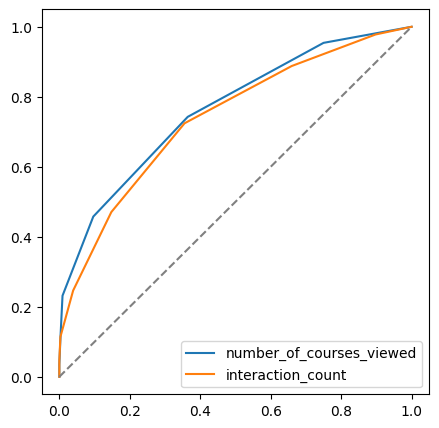

In [109]:
plt.figure(figsize=(5, 5))

fpr, tpr, _ = roc_curve(y_train, df_train.number_of_courses_viewed)
plt.plot(fpr, tpr, label='number_of_courses_viewed')

fpr, tpr, _ = roc_curve(y_train, df_train.interaction_count)
plt.plot(fpr, tpr, label='interaction_count')

plt.plot([0, 1], [0, 1], color='grey', linestyle='--')

plt.legend()
plt.show()

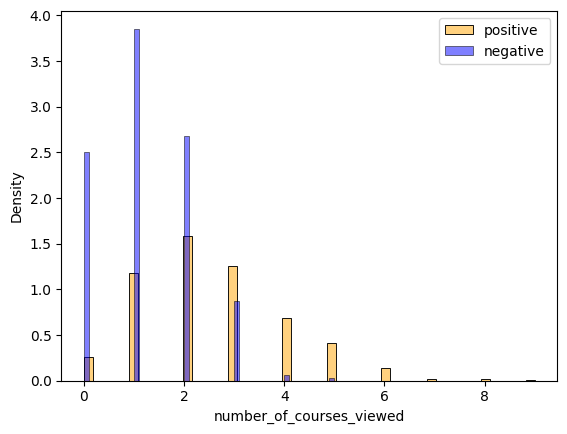

In [110]:
sns.histplot(df_train.number_of_courses_viewed[y_train == 1],
             stat='density', bins=50,
             color='orange', alpha=0.5,
             label='positive')
sns.histplot(df_train.number_of_courses_viewed[y_train == 0],
             stat='density', bins=50,
             color='blue', alpha=0.5,
             label='negative')

plt.legend()
plt.show()

# 4.5 Training logistic regression

### One-Hot Encoding
- Use Scikit-Learn to encode categorical features

In [111]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

Training split

In [112]:
train_dict = df_train.to_dict(orient='records')
dv = DictVectorizer(sparse=False) # sparse set to false to use np array matrix
X_train = dv.fit_transform(train_dict) # does the fit then tranformation at once instead of 2 steps

In [113]:
dv.get_feature_names_out()

array(['annual_income', 'employment_status=NA',
       'employment_status=employed', 'employment_status=self_employed',
       'employment_status=student', 'employment_status=unemployed',
       'industry=NA', 'industry=education', 'industry=finance',
       'industry=healthcare', 'industry=manufacturing', 'industry=other',
       'industry=retail', 'industry=technology', 'interaction_count',
       'lead_score', 'lead_source=NA', 'lead_source=events',
       'lead_source=organic_search', 'lead_source=paid_ads',
       'lead_source=referral', 'lead_source=social_media', 'location=NA',
       'location=africa', 'location=asia', 'location=australia',
       'location=europe', 'location=middle_east',
       'location=north_america', 'location=south_america',
       'number_of_courses_viewed'], dtype=object)

In [114]:
model = LogisticRegression(C=1.0, max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [115]:
X_train.shape

(876, 31)

Validation split

In [116]:
val_dict = df_val.to_dict(orient='records')

In [117]:
# why tranform only? Validation must use the same feature columns learned from train. 
# which is already fitted
X_val = dv.transform(val_dict)

In [118]:
X_val.shape

(293, 31)

In [119]:
y_pred = model.predict_proba(X_val)[:, 1] # only interested in the 2nd column, RHS (YES)

# 4.6 Accuracy

### ROC AUC
- Area under the ROC curve - useful metric
- Interpretation of AUC

$
\text{Higher AUC} \Rightarrow \text{Better overall classification performance}
$

In [120]:
from sklearn.metrics import roc_auc_score

In [121]:
roc_auc_score(y_val, y_pred)

0.9200460166810468

### Precision and Recall

#### confusin matrix

```text
                    Predicted
                ┌───────────┬───────────┐
                │     0     │     1     │
┌───────────────┼───────────┼───────────┤
│ Actual 0      │    TN     │    FP     │
│ (No Churn)    │   Correct │   Wrong   │
├───────────────┼───────────┼───────────┤
│ Actual 1      │    FN     │    TP     │
│ (Churn)       │   Wrong   │  Correct  │
└───────────────┴───────────┴───────────┘

In [122]:
def confusion_matrix_dataframe(y_val, y_pred):
    scores = []
    
    thresholds = np.linspace(0, 1, 101)
    
    for t in thresholds:
        # actual values
        actual_positive = (y_val == 1)
        actual_negative = (y_val == 0)
        
        predict_positive = (y_pred >= t)
        predict_negative = (y_pred < t)
        
        # confusion matrix values
        tp = (predict_positive & actual_positive).sum()
        tn = (predict_negative & actual_negative).sum()
        
        fp = (predict_positive & actual_negative).sum()
        fn = (predict_negative & actual_positive).sum()
    
    
        scores.append((t, tp, fp, fn, tn))

    columns = ['threshold', 'tp', 'fp', 'fn', 'tn']
    df_scores = pd.DataFrame(scores, columns=columns)

    return df_scores
   
    

In [123]:
df_scores = confusion_matrix_dataframe(y_val, y_pred)

In [124]:
df_scores[::10]

,threshold,tp,fp,fn,tn
0,0.0,171,122,0,0
10,0.1,168,93,3,29
20,0.2,165,68,6,54
30,0.3,164,50,7,72
40,0.4,157,31,14,91
50,0.5,153,25,18,97
60,0.6,143,16,28,106
70,0.7,135,11,36,111
80,0.8,124,7,47,115
90,0.9,99,6,72,116


In [125]:
# p = tp / (tp + fp) precision
df_scores['p'] = df_scores.tp / (df_scores.tp + df_scores.fp)

# tpr = tp / (tp + fn)  recall
df_scores['r'] = df_scores.tp / (df_scores.tp + df_scores.fn)

In [126]:
# absolute difference between precision and recall
df_scores['diff'] = (df_scores['p'] - df_scores['r']).abs()

# row where they are closest
idx = df_scores['diff'].idxmin()

intersection_threshold = df_scores.loc[idx, 'threshold']
intersection_precision = df_scores.loc[idx, 'p']
intersection_recall = df_scores.loc[idx, 'r']

print("Threshold:", intersection_threshold)
print("Precision:", intersection_precision)
print("Recall:", intersection_recall)

Threshold: 0.53
Precision: 0.872093023255814
Recall: 0.8771929824561403


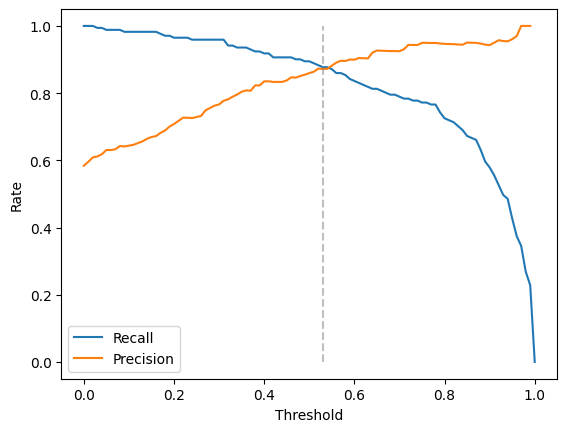

In [127]:
plt.plot(df_scores.threshold, df_scores['r'], label='Recall')
plt.plot(df_scores.threshold, df_scores['p'], label='Precision')

plt.vlines(intersection_threshold, 0, 1, color='grey', linestyle='--', alpha=0.5)

plt.xlabel('Threshold')
plt.ylabel('Rate')
plt.legend()
plt.show()

### F1 SCORE

**F1 Score** is a single metric that combines:

- **Precision**
- **Recall**

It is especially useful in **binary classification** (like Logistic Regression) when you want a balance between:

- avoiding **false positives** → Precision
- avoiding **false negatives** → Recall

---

#### F1 SCORE FORMULA

$$ 
\large F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}
$$

$$ \text OR $$ 

$$
\large F1 = 2 \times \frac{TP}{2TP + FP + FN}
$$

---

```text
Predictions from Logistic Regression
              │
              ▼
      Confusion Matrix
   (TP, FP, TN, FN)
              │
      ┌───────┴───────┐
      ▼               ▼
 Precision         Recall
 TP / (TP+FP)     TP / (TP+FN)
      └───────┬───────┘
              ▼
           F1 Score
  2 × (P × R) / (P + R)


In [128]:
df_scores = df_scores.drop(columns='diff')

In [129]:
df_scores['f1'] = 2 * df_scores.p * df_scores.r / (df_scores.p + df_scores.r)

At which threshold F1 is maximal?

In [130]:
df_scores.loc[df_scores.f1.argmax()]

threshold      0.520000
tp           151.000000
fp            22.000000
fn            20.000000
tn           100.000000
p              0.872832
r              0.883041
f1             0.877907
Name: 52, dtype: float64

In [131]:
max_threshold = df_scores.loc[df_scores.f1.argmax()]['threshold']

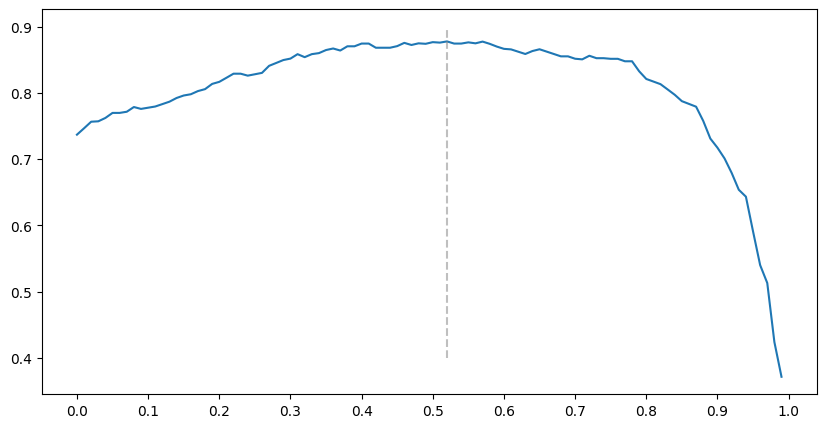

In [132]:
plt.figure(figsize=(10, 5))

plt.plot(df_scores.threshold, df_scores.f1)
plt.vlines(max_threshold, 0.4, 0.9, color='grey', linestyle='--', alpha=0.5)

plt.xticks(np.linspace(0, 1, 11))
plt.show()

# 4.7 K-Fold Cross-Validation

In [133]:
from sklearn.model_selection import KFold
from tqdm.auto import tqdm

import warnings
warnings.filterwarnings('ignore')

In [134]:
def train(df_train, y_train, C=1.0):
    dicts = df_train[categorical_columns + numerical_columns].to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(solver='liblinear', C=C, max_iter=1000)
    model.fit(X_train, y_train)
    
    return dv, model

In [135]:
def predict(df, dv, model):
    dicts = df[categorical_columns + numerical_columns].to_dict(orient='records')

    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:, 1]

    return y_pred

In [136]:
kfold = KFold(n_splits=5, shuffle=True, random_state=1)

In [137]:
scores = []

kfold = KFold(n_splits=5, shuffle=True, random_state=1)

for train_idx, val_idx in kfold.split(df_full_train):
    df_train = df_full_train.iloc[train_idx]
    df_val = df_full_train.iloc[val_idx]

    y_train = df_train.converted.values
    y_val = df_val.converted.values

    dv, model = train(df_train, y_train, C=1.0)
    y_pred = predict(df_val, dv, model)

    auc = roc_auc_score(y_val, y_pred)
    scores.append(auc)

print('%.3f +- %.3f' % (np.mean(scores), np.std(scores)))

0.822 +- 0.036


In [138]:
 scores

[0.8060745924216483,
 0.8713738368910783,
 0.7754320118852139,
 0.8018368617683685,
 0.8558272713202291]

# 4.8 Hyperparemeter Tuning

Now let's use 5-Fold cross-validation to find the best parameter C

- Iterate over the following C values: [0.01, 0.1, 0.5, 10]
- Initialize KFold with the same parameters as previously
- Use these parametes for the model: LogisticRegression(solver='liblinear', C=C, max_iter=1000)
- Compute the mean score as well as the std (round the mean and std to 3 decimal digits)

In [139]:
kfold = KFold(n_splits=5, shuffle=True, random_state=1)

for C in [0.000001, 0.001, 1]:
    scores = []

    for train_idx, val_idx in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]

        y_train = df_train.converted.values
        y_val = df_val.converted.values

        dv, model = train(df_train, y_train, C=C)
        y_pred = predict(df_val, dv, model)

        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)

    print('C=%4s, %.3f +- %.3f' % (C, np.mean(scores), np.std(scores)))

C=1e-06, 0.560 +- 0.024
C=0.001, 0.867 +- 0.029
C=   1, 0.822 +- 0.036
